In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from scipy.optimize import minimize

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    #"figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "figure.figsize": (11.6, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [3]:
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data_50 = pd.read_csv(file_path, header=None)
file_path2 = "csv-files/new_data.csv"
data_30 = pd.read_csv(file_path2, header=None)

spectrum_50 = data_50[0].values
spectrum_30 = data_30[0].values


t_50 = 4279386 # 50 days exposure
t_30 = 2827661 # 50 days exposure

t_tot = t_50 + t_30



In [4]:
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev_50 =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev_50>=0) & (E_kev_50 <= 3000)
E_kev_50 = E_kev_50[mask]
spectrum_50 = spectrum_50[mask]
spectrum_50_norm = spectrum_50/t_50


file_path = "csv-files/bkg.csv"
data = pd.read_csv(file_path, header=None)
spectrum_bkg = data[0].values
t_bkg = 4143234 # 40 days exposure
spectrum_bkg = spectrum_bkg[mask]

In [5]:
b_30 = 2.78
a_30 = 0.4142675
c_30  = 8.4771*1e-7
E_kev_30 =  np.arange(len(spectrum_30)) * a_30 + b_30 + c_30 * np.arange(len(spectrum_30))**2
mask = (E_kev_30>=0) & (E_kev_30 <= 3000)
E_kev_30 = E_kev_30[mask]
spectrum_30 = spectrum_30[mask]
spectrum_30_norm = spectrum_30/t_30



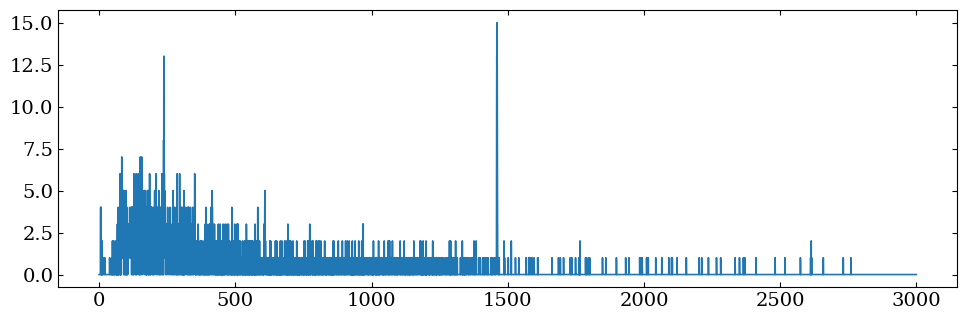

In [56]:
plt.plot(E_kev_50, spectrum_bkg
        )

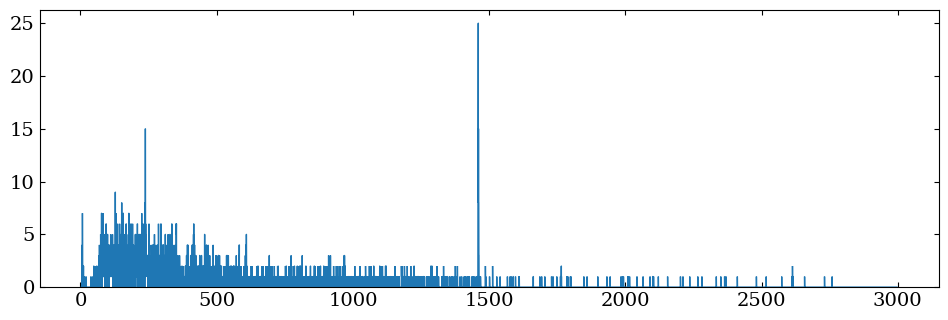

In [62]:
bin_edges = np.arange(0, 3000 + 0.4, 0.4)

n, e, _ = plt.hist(
    E_kev_50,
    bins=bin_edges,
    weights=spectrum_bkg,
    histtype='step',
    label="bkgs"
)

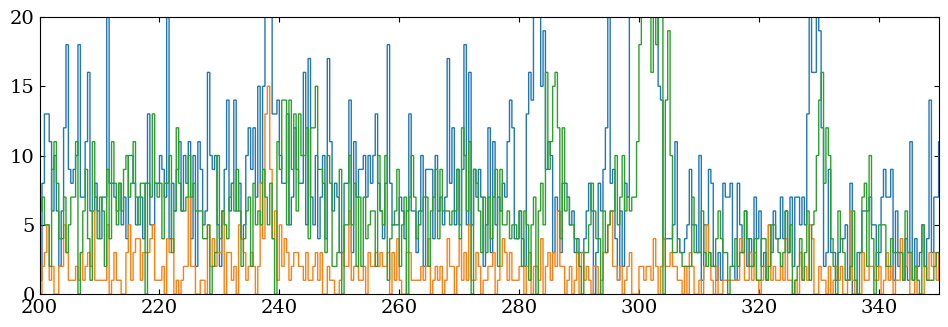

In [73]:
db = 0.4
bins_common = np.arange(0,3000+db,db)

N50, bin_edge50,_ = plt.hist(E_kev_50, bins = bins_common, weights = spectrum_50 , histtype='step' )
Nbkg, bin_edgebkg , _= plt.hist(E_kev_50, bins = bins_common, weights = spectrum_bkg , histtype='step' )
N30, bin_edge30, _ =plt.hist(
    E_kev_30,
    bins=bins_common,
    weights=spectrum_30,
    histtype='step',
    label="bkgs"
)
plt.xlim([200,350])
plt.ylim(0,20)
E_tot = (bin_edge50[1:] + bin_edge50[:-1])/2

Ntot = N50 + N30

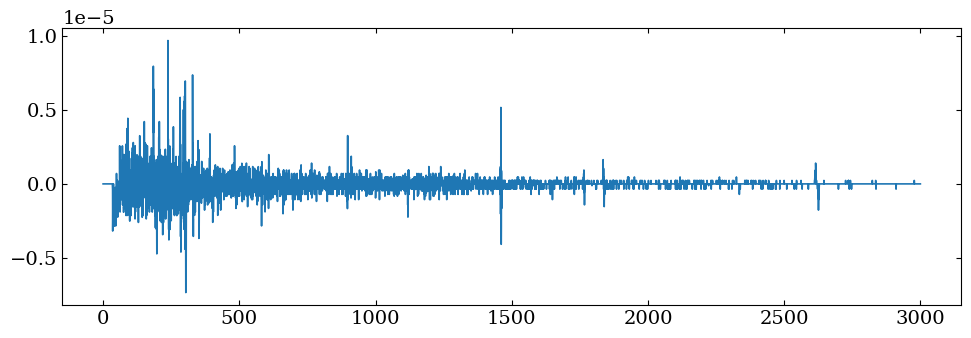

In [72]:
plt.plot(E_tot , (N50/t_50 - N30/t_30))

In [69]:
'''
plt.figure()
ax = plt.gca()


dx_major = 150
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width

#bins_common = np.arange(15,3000,0.4)

plt.step(
    E_tot,
    Ntot/t_tot,
    where='mid',
    linewidth = 0.5
        
)

plt.step(
    E_tot,
    Nbkg/t_bkg,
    where='mid',
    linewidth = 0.5
        
)


plt.fill_between(
    E_tot,
    Ntot/t_tot,
    step='mid',
    #alpha=0.85,
    label = f"Sample total exposure = {(t_50 + t_30)/(24*60*60) :.2f} days"
)


plt.fill_between(
    E_tot,
    Nbkg/t_bkg,
    step='mid',
    #alpha=0.85,
    label = f"Background total exposure = {(t_bkg)/(24*60*60) :.2f} days"
)



db = (E_tot[1]-E_tot[0]) 

plt.xlim([200,350])
plt.ylim([1e-7, 4e-5])
plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts /  keV $\cdot$ s')
plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize=15)

plt.vlines(583.19, 1,100)
plt.savefig("spectrum_50_days.png")
plt.show()
'''

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_5279/1186684145.py:1: SyntaxWarning: invalid escape sequence '\c'
  '''


'\nplt.figure()\nax = plt.gca()\n\n\ndx_major = 150\ndx_minor = 100\n\nax.xaxis.set_major_locator(MultipleLocator(dx_major))\nax.xaxis.set_minor_locator(MultipleLocator(dx_minor))\ndy_major = 100\ndy_minor = 20\n\nax.yaxis.set_major_locator(MultipleLocator(dy_major))\nax.yaxis.set_minor_locator(MultipleLocator(dy_minor))\n\nax.tick_params(axis=\'x\', which=\'major\', length=7, labelsize=10)\n#ax.tick_params(axis=\'x\', which=\'minor\', length=4)\n\nax.tick_params(axis=\'y\', which=\'major\', length=7, labelsize=10)\nax.tick_params(axis=\'y\', which=\'minor\', length=4)\n\n# Bin width\n\n#bins_common = np.arange(15,3000,0.4)\n\nplt.step(\n    E_tot,\n    Ntot/t_tot,\n    where=\'mid\',\n    linewidth = 0.5\n\n)\n\nplt.step(\n    E_tot,\n    Nbkg/t_bkg,\n    where=\'mid\',\n    linewidth = 0.5\n\n)\n\n\nplt.fill_between(\n    E_tot,\n    Ntot/t_tot,\n    step=\'mid\',\n    #alpha=0.85,\n    label = f"Sample total exposure = {(t_50 + t_30)/(24*60*60) :.2f} days"\n)\n\n\nplt.fill_between(\

In [10]:
E_tot = (bin_edge50[1:] + bin_edge50[:-1])/2

Ntot = N50 + N30

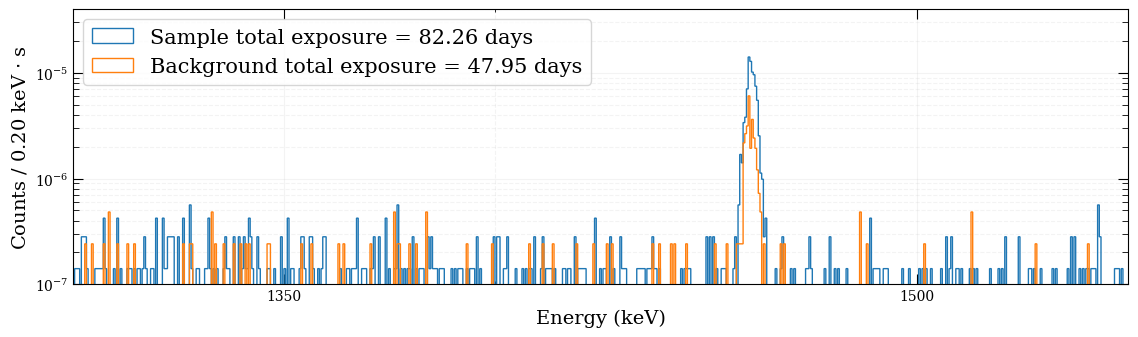

In [ ]:

plt.figure()
ax = plt.gca()


dx_major = 150
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width
db = 0.4
bins_common = np.arange(0,3000+db,db)


_ = plt.hist(E_tot, bins = bins_common, 
             weights = Ntot/t_tot, histtype='step', 
             histtype='stepfilled',
            alpha=0.6,  
             label = f"Sample total exposure = {(t_50 + t_30)/(24*60*60) :.2f} days" )



c, bc, _= plt.hist(E_tot, bins = bins_common, 
                   weights = Nbkg/t_bkg ,
                     histtype='step', 
                     histtype='stepfilled',
                    alpha=0.6,
                     label = f"Background total exposure = {(t_bkg)/(24*60*60) :.2f} days")


db_plot = (bc[1]-bc[0]) / 2

#plt.xlim([25,3000])
plt.ylim([1e-7, 4e-5])
plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db_plot:.2f} keV $\cdot$ s')
plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize=15)

plt.savefig("spectrum_50_days.png")
plt.show()
